## Import

In [1]:
import sys
#!{sys.executable} -m pip install seaborn

In [2]:
import os

print("LAL_DATA_PATH:", os.environ["LAL_DATA_PATH"])
print(
    "exists:",
    os.path.exists(
        "/pbs/home/a/amahdi/lal_data/SEOBNRv5HMROM_v1.0.hdf5"
    )
)

LAL_DATA_PATH: /pbs/home/a/amahdi/lal_data
exists: True


In [3]:
import os
import h5py
import itertools
import copy
import numpy as np
import json
import scipy
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap, ScalarMappable
import matplotlib as mpl
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd

from tqdm import tqdm as tqdm

from astropy.cosmology import Planck15 as cosmo

# Notebook-safe plotting: do not require an external LaTeX install.
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"


In [4]:
import sys
print(sys.executable)

/pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python


In [5]:
import lisabeta
import lisabeta.tgr.fti as fti
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils
import lisabeta.inference.inference as inference
import lisabeta.utils.plotutils as plotutils

import lisabeta.waveforms.bbh.tf2 as tf2
import lal

/pbs/home/a/amahdi/lisabeta/src/lisabeta/waveforms/bbh/lalsim_wrap.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [6]:
print(lal.__path__)

['/pbs/home/a/amahdi/.conda/envs/lisabeta/lalsuite_for_lisabeta/lib/python3.10/site-packages/lal']


In [7]:
%matplotlib inline

## Definitions

In [8]:
def plot_postraw_lnL_trace(post_raw, rangey=None, title=''):
    nwalkers = post_raw['lnL'].shape[0]
    nsteps = post_raw['lnL'].shape[1]

    # Threshold to eliminate the -1e99 values that mess up plots
    masks = [post_raw['lnL'][i] > -1e12 for i in range(nwalkers)]
    names = ['lnL', 'Mchirp', 'q', 'chiPN', 'chim', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']
    nrows = len(names)

    fig, axes = plt.subplots(nrows, 1, figsize=[16, 4 * nrows])

    # Plot the first plot
    ax = axes[0]
    plotutils.llogplot(ax, *[[np.arange(nsteps)[masks[i]], -post_raw['lnL'][i][masks[i]]] for i in range(nwalkers)], rangey=rangey)
    ax.set_xlabel(r'$\mathrm{Steps}$')
    ax.set_ylabel(r'$-\ln \mathcal{L}$')
    ax.set_title(title)

    # Plot the rest
    for ax, name in zip(axes[1:], names[1:]):
        plotutils.llogplot(ax, *[[np.arange(nsteps), post_raw[name][i]] for i in range(nwalkers)])
        ax.set_xlabel(r'$\mathrm{Steps}$')
        ax.set_ylabel(r'$\mathrm{' + name + '}$')
        ax.set_title(title)

    plt.tight_layout()
    return fig

In [9]:
'''def chipofchiPNchim(chiPN, chim, q):
    return 1./94 * (113*chiPN - (q-1.)/(q+1.)*19*chim)'''

'def chipofchiPNchim(chiPN, chim, q):\n    return 1./94 * (113*chiPN - (q-1.)/(q+1.)*19*chim)'

In [10]:
def inner_product(a, b, Sn, delta_f):
    # The factor of 4 comes from the definition of the one-sided PSD inner product
    integrand = np.real(a * np.conj(b)) / Sn
    return 4 * delta_f * np.sum(integrand)

def overlap_AET_data(data1, data2, psd):
    # Assumes frequencies and TDI content consistent in inputs
    freq = data1['freq']
    diff_freq = np.diff(freq)
    tdikeys = [tdi for tdi in data1.keys() if not tdi=='freq']
    overlap = 0.
    for tdi in tdikeys:
        integrand = 4 * np.real(data1[tdi] * np.conj(data2[tdi])) / psd[tdi]
        overlap += np.sum(diff_freq * (integrand[1:] + integrand[:-1])/2)
    return overlap

In [11]:
def dh_deltah_data_smbh(params, deltah_data, steps=None, list_params=lisa_fisher.default_list_fisher_params_smbh, list_fixed_params=[], Lframe=False, fLow_from_22=True, **waveform_params):
    '''
    This updated version of Fisher computation:
      1. Adds options for additional mass parameter combinations
      2. Adds option for providing a "prior" inverse covariance which is added to the Fisher matrix
      3. Default is as before
    '''

    waveform_params = copy.deepcopy(waveform_params)

    # Parameters
    Npar = len(list_params)

    LISAnoise = waveform_params.get('LISAnoise', pyLISAnoise.LISAnoiseSciRDv1)
    TDI = waveform_params.get('TDI', 'TDIAET')
    if not TDI=='TDIAET':
        raise ValueError('Data is using TDI channels among A,E,T, must have TDI=TDIAET or TDI2AET')
    TDIrescaled = waveform_params.get('TDIrescaled', True)
    LISAconst = waveform_params.get('LISAconst', pyresponse.LISAconstProposal)

    # Convert input parameters to either Lframe or SSBframe
    if not params.get('Lframe', False) and Lframe:
        params_base = lisatools.convert_SSBframe_to_Lframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    elif params.get('Lframe', False) and not Lframe:
        params_base = lisatools.convert_Lframe_to_SSBframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    else:
        params_base = params.copy()

    # Masses and spins
    params_base = pytools.complete_mass_params(params_base)
    params_base = pytools.complete_spin_params(params_base)
    m1 = params_base['m1']
    m2 = params_base['m2']
    M = params_base['M']
    Ms = M * pyconstants.MTSUN_SI

    # Identify TDI channels present in data, and translate conventions
    tdi_channels = [k for k in deltah_data.keys() if not k=='freq']
    tdi_translate = {'TDIA':'chan1', 'TDIE':'chan2', 'TDIT':'chan3'}
    channels = [tdi_translate[k] for k in tdi_channels]
    deltah = dict([(tdi_translate[k], deltah_data[k]) for k in tdi_channels])

    # Generate base waveform, with frequency bounds from waveform_params
    # e.g. scale_freq_hm might be True or False
    wftdi_base = lisa.GenerateLISATDI_SMBH(params_base, **waveform_params)

    # Read set of modes and dict of mode-by-mode freq bounds from base waveform
    modes = wftdi_base['modes']
    fLow_lm = dict([(lm,wftdi_base[lm]['freq'][0]) for lm in modes])
    fHigh_lm = dict([(lm,wftdi_base[lm]['freq'][-1]) for lm in modes])
    # Option to ignore low freqs where only 21 has support
    # This 21-specific frequency range is costly to cover with 22-based grid
    # but normally low SNR
    if fLow_from_22:
        fLow = fLow_lm[(2,2)]
    else:
        fLow = np.min([fLow_lm[lm] for lm in modes])
    fHigh = np.max([fHigh_lm[lm] for lm in modes])

    # We do not assume that deltaf is constant
    freqs = deltah_data['freq']
    df = np.diff(freqs)

    # Freq series at base point - force the use of the same gridfreq everywhere
    # gridfreq is a dictionary if hm present, a np array if not
    if modes==[(2,2)]:
        gridfreq = wftdi_base[(2,2)]['freq'].copy()
    else:
        gridfreq = dict([(lm,wftdi_base[lm]['freq'].copy()) for lm in modes])
    waveform_params['gridfreq'] = gridfreq
    # This generates the wf on the input gridfreq, fixed to be the same as base
    # and then interpolates on the large frequency array freqs
    tdifreqseries_base = lisa.GenerateLISATDIFreqseries_SMBH(params_base, freqs, **waveform_params)

    # Get pair of mass/spin params
    # Must have 2 mass, spin params in list_params + list_fixed_params together
    # When varying one param, one needs to specify which 2nd param is fixed
    list_mass_params = [p for p in list_params if p in pytools.list_mass_params]
    list_spin_params = [p for p in list_params if p in pytools.list_spin_params]
    list_fixed_mass_params = [p for p in list_fixed_params if p in pytools.list_mass_params]
    list_fixed_spin_params = [p for p in list_fixed_params if p in pytools.list_spin_params]
    list_pair_mass_params = list_mass_params + list_fixed_mass_params
    list_pair_spin_params = list_spin_params + list_fixed_spin_params
    if (not len(list_mass_params)+len(list_fixed_mass_params)==2) or (not len(list_spin_params)+len(list_fixed_spin_params)==2):
        raise ValueError('list_params + list_fixed_params must have 2 mass and spin params.')
    # The only fully degenerate pair is (q,eta)
    if list_pair_mass_params==['q', 'eta'] or list_pair_mass_params==['eta', 'q']:
        raise ValueError('Mass params pair (q,eta) is fully degenerate.')
    # Remove redundant parameters: keep only relevant pair of mass/spin params
    params_base_pair_massspin = params_base.copy()
    for p in pytools.list_mass_params:
        params_base_pair_massspin.pop(p, None)
    for p in pytools.list_spin_params:
        params_base_pair_massspin.pop(p, None)
    for p in list_pair_mass_params + list_pair_spin_params:
        params_base_pair_massspin[p] = params_base[p]

    # Compute noises
    noise_evaluator = pyLISAnoise.initialize_noise(LISAnoise,
                                        TDI=TDI, TDIrescaled=TDIrescaled,
                                        LISAconst=LISAconst)
    Sn1_vals, Sn2_vals, Sn3_vals = pyLISAnoise.evaluate_noise(
                          noise_evaluator, freqs,
                          TDI=TDI, TDIrescaled=TDIrescaled, LISAconst=LISAconst)
    Snvals = {}
    Snvals['chan1'] = Sn1_vals
    Snvals['chan2'] = Sn2_vals
    Snvals['chan3'] = Sn3_vals

    # Get default steps with M-dependency
    steps_default = lisa_fisher.get_default_steps_smbh(M)
    if steps is None:
        steps = steps_default
    else:
        steps_tmp = copy.deepcopy(steps_default)
        steps_tmp.update(steps)
        steps = steps_tmp

    # Signals shifted by parameter steps
    params_step = {}
    dh = {}
    for p in list_params:
        frac = lisa_fisher.dict_params_fractional[p]
        params_step = params_base_pair_massspin.copy()
        if frac:
            params_step[p] *= 1 + steps[p]
        else:
            params_step[p] += steps[p]
        params_step = pytools.complete_mass_params(params_step)
        params_step = pytools.complete_spin_params(params_step)

        tdifreqseries_step = lisa.GenerateLISATDIFreqseries_SMBH(params_step, freqs, **waveform_params)

        # Compute signal derivatives dh/dp
        dh[p] = {}
        for chan in channels:
            dh[p][chan] = np.zeros_like(freqs, dtype=complex)
            for lm in modes:
                dh[p][chan] += (tdifreqseries_step[lm][chan] - tdifreqseries_base[lm][chan]) / steps[p]

    # Compute ( dh | delta h)
    beta = np.zeros(Npar, dtype=float)
    for i in range(Npar):
        beta[i] = 0.
        pi = list_params[i]
        for chan in channels:
            beta[i] += 4*np.sum(df * np.real(dh[pi][chan] * np.conj(deltah[chan]) / Snvals[chan])[:-1])

    # Scale back parameters with fractional steps
    scales = np.ones(len(list_params))
    for i,p in enumerate(list_params):
        if lisa_fisher.dict_params_fractional[p]:
            scales[i] = 1./params_base[p]
    scales_diag = np.diag(scales)
    scales_diag_inv = np.diag(1./scales)

    beta = np.dot(scales_diag, beta)
    
    return beta

In [12]:
def fisher_covariance_data_grid_smbh(
    params,
    reference_data,
    steps=None,
    list_params=lisa_fisher.default_list_fisher_params_smbh,
    list_fixed_params=[],
    Lframe=False,
    fLow_from_22=True,
    rcond=1e-12,
    **waveform_params
):
    """
    Fisher covariance evaluated on exactly the same frequency grid and TDI channels
    present in `reference_data`.

    This mirrors dh_deltah_data_smbh, but computes (dh_i|dh_j) instead of
    (dh_i|delta h). It avoids the old inconsistency where beta used the
    injected data grid while Fisher used an internally generated nyquist grid.
    """
    waveform_params = copy.deepcopy(waveform_params)
    Npar = len(list_params)

    LISAnoise = waveform_params.get('LISAnoise', pyLISAnoise.LISAnoiseSciRDv1)
    TDI = waveform_params.get('TDI', 'TDIAET')
    if not TDI == 'TDIAET':
        raise ValueError('Data is using TDI channels among A,E,T, so use TDI=TDIAET here.')
    TDIrescaled = waveform_params.get('TDIrescaled', True)
    LISAconst = waveform_params.get('LISAconst', pyresponse.LISAconstProposal)

    # Convert input parameters to either L-frame or SSB-frame consistently.
    if not params.get('Lframe', False) and Lframe:
        params_base = lisatools.convert_SSBframe_to_Lframe(
            params,
            t0=waveform_params['t0'],
            frozenLISA=waveform_params['frozenLISA']
        )
    elif params.get('Lframe', False) and not Lframe:
        params_base = lisatools.convert_Lframe_to_SSBframe(
            params,
            t0=waveform_params['t0'],
            frozenLISA=waveform_params['frozenLISA']
        )
    else:
        params_base = params.copy()

    params_base = pytools.complete_mass_params(params_base)
    params_base = pytools.complete_spin_params(params_base)

    m1 = params_base['m1']
    m2 = params_base['m2']
    M = params_base['M']

    # Use only the channels actually present in the data/residual.
    tdi_channels = [k for k in ['TDIA', 'TDIE', 'TDIT'] if k in reference_data]
    if not tdi_channels:
        raise ValueError("reference_data must contain at least one of TDIA, TDIE, TDIT.")

    tdi_translate = {'TDIA': 'chan1', 'TDIE': 'chan2', 'TDIT': 'chan3'}
    channels = [tdi_translate[k] for k in tdi_channels]

    freqs = np.asarray(reference_data['freq'])
    df = np.diff(freqs)

    # Generate base waveform once to obtain the mode support and fixed gridfreq.
    wftdi_base = lisa.GenerateLISATDI_SMBH(params_base, **waveform_params)
    modes = wftdi_base['modes']

    if modes == [(2, 2)]:
        gridfreq = wftdi_base[(2, 2)]['freq'].copy()
    else:
        gridfreq = {lm: wftdi_base[lm]['freq'].copy() for lm in modes}

    waveform_params['gridfreq'] = gridfreq
    tdifreqseries_base = lisa.GenerateLISATDIFreqseries_SMBH(params_base, freqs, **waveform_params)

    # Same mass/spin-pair bookkeeping as lisa_fisher/dh_deltah_data_smbh.
    list_mass_params = [p for p in list_params if p in pytools.list_mass_params]
    list_spin_params = [p for p in list_params if p in pytools.list_spin_params]
    list_fixed_mass_params = [p for p in list_fixed_params if p in pytools.list_mass_params]
    list_fixed_spin_params = [p for p in list_fixed_params if p in pytools.list_spin_params]
    list_pair_mass_params = list_mass_params + list_fixed_mass_params
    list_pair_spin_params = list_spin_params + list_fixed_spin_params

    if (not len(list_pair_mass_params) == 2) or (not len(list_pair_spin_params) == 2):
        raise ValueError('list_params + list_fixed_params must have 2 mass and 2 spin params.')
    if list_pair_mass_params == ['q', 'eta'] or list_pair_mass_params == ['eta', 'q']:
        raise ValueError('Mass params pair (q, eta) is fully degenerate.')

    params_base_pair_massspin = params_base.copy()
    for p in pytools.list_mass_params:
        params_base_pair_massspin.pop(p, None)
    for p in pytools.list_spin_params:
        params_base_pair_massspin.pop(p, None)
    for p in list_pair_mass_params + list_pair_spin_params:
        params_base_pair_massspin[p] = params_base[p]

    # Noise on the same frequency grid.
    noise_evaluator = pyLISAnoise.initialize_noise(
        LISAnoise,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst
    )
    Sn1_vals, Sn2_vals, Sn3_vals = pyLISAnoise.evaluate_noise(
        noise_evaluator,
        freqs,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst
    )
    Snvals = {'chan1': Sn1_vals, 'chan2': Sn2_vals, 'chan3': Sn3_vals}

    steps_default = lisa_fisher.get_default_steps_smbh(M)
    if steps is None:
        steps = steps_default
    else:
        steps_tmp = copy.deepcopy(steps_default)
        steps_tmp.update(steps)
        steps = steps_tmp

    # Derivatives on the same freqs and channels.
    dh = {}
    for p in list_params:
        frac = lisa_fisher.dict_params_fractional[p]
        params_step = params_base_pair_massspin.copy()
        if frac:
            params_step[p] *= 1 + steps[p]
        else:
            params_step[p] += steps[p]

        params_step = pytools.complete_mass_params(params_step)
        params_step = pytools.complete_spin_params(params_step)

        tdifreqseries_step = lisa.GenerateLISATDIFreqseries_SMBH(params_step, freqs, **waveform_params)

        dh[p] = {}
        for chan in channels:
            dh[p][chan] = np.zeros_like(freqs, dtype=complex)
            for lm in modes:
                dh[p][chan] += (
                    tdifreqseries_step[lm][chan]
                    - tdifreqseries_base[lm][chan]
                ) / steps[p]

    fish = np.zeros((Npar, Npar), dtype=float)

    for i, pi in enumerate(list_params):
        for j, pj in enumerate(list_params[i:], start=i):
            val = 0.0
            for chan in channels:
                integrand = np.real(dh[pi][chan] * np.conj(dh[pj][chan]) / Snvals[chan])
                val += 4.0 * np.sum(df * integrand[:-1])
            fish[i, j] = val
            fish[j, i] = val

    # Scale back parameters with fractional steps, matching dh_deltah_data_smbh.
    scales = np.ones(len(list_params))
    for i, p in enumerate(list_params):
        if lisa_fisher.dict_params_fractional[p]:
            scales[i] = 1.0 / params_base[p]

    scales_diag = np.diag(scales)
    fish = scales_diag @ fish @ scales_diag

    cond = np.linalg.cond(fish)
    try:
        cov = np.linalg.inv(fish)
        inversion = "inv"
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(fish, rcond=rcond)
        inversion = f"pinv(rcond={rcond:g})"

    return {
        'fish': fish,
        'cov': cov,
        'freq': freqs,
        'channels': tdi_channels,
        'list_params': list_params,
        'condition_number': cond,
        'inversion': inversion,
    }

In [13]:
def format_mass_title(mass_str, use_latex=True):
    """
    Converts 'me5' -> '10^5' or '2me5' -> '2*10^5'
    If use_latex=True, converts to '$10^5$' or '$2 \\times 10^5$' for beautiful plots.
    """
    clean_str = mass_str.lower()
    parts = clean_str.split('me')
    
    if len(parts) != 2:
        return mass_str  # Return original if it doesn't match the format
        
    mantissa, exponent = parts
    
    # Case 1: No number before 'me' (e.g., 'me5')
    if mantissa == '':
        if use_latex:
            return fr"$M = 10^{{{exponent}}} M_{{\odot}}$"
        else:
            return f"10^{exponent}"
            
    # Case 2: Number before 'me' (e.g., '2me5')
    else:
        if use_latex:
            return fr"${mantissa} \\times 10^{{{exponent}}}  M_{{\odot}}$"
        else:
            return f"{mantissa}*10^{exponent}"

In [14]:
import os
import h5py

# Absolute directory shared with the injection notebook.
subsdir = "/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set"
datadir = "/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set"

print("datadir:", datadir)
print("datadir absolute:", os.path.abspath(datadir))


datadir: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set
datadir absolute: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set


## Parameters

In [15]:
mass = 'me6'
m_str = 'M1e6'
inj_id = 0

wf_rec = 'SEOB'

if wf_rec == 'SEOB': 
    wf_name = 'SEOBNRv5HMROM'
elif wf_rec == 'XHM': 
    wf_name = 'PhenomXHM'
else:
    raise ValueError(f"Unknown wf_rec = {wf_rec}")

mass_name = format_mass_title(mass)

# GR-only run: FTI parameters are explicitly zero but inactive.
FTI_ZERO_PARAMS = [
    "fti_dchiMinus2v", "fti_dchi0v", "fti_dchi1v", "fti_dchi2v",
    "fti_dchi3v", "fti_dchi4v", "fti_dchi5lv", "fti_dchi6v",
    "fti_dchi6lv", "fti_dchi7v", "fti_dkappa_S", "fti_dxi0v",
]
fti_param = "fti_dchiMinus2v"

# Load injection parameters from the exact directory used by the injection notebook.
params_file = os.path.join(datadir, f"params_injection_set_{m_str}.h5")
data_file = os.path.join(datadir, m_str, f"data_pseob_{m_str}_id_{inj_id}.h5")

print("Reading params:", params_file)
print("Reading data:  ", data_file)

with h5py.File(params_file, 'r') as hf:
    params = {
        'M': float(hf['M'][inj_id]),
        'q': float(hf['q'][inj_id]),
        'chi1': float(hf['chi1'][inj_id]),
        'chi2': float(hf['chi2'][inj_id]),
        'dist': float(hf['dist'][inj_id]),
        'inc': float(hf['inc'][inj_id]),
        'phi': float(hf['phi'][inj_id]),
        'lambda': float(hf['lambda'][inj_id]),
        'beta': float(hf['beta'][inj_id]),
        'psi': float(hf['psi'][inj_id]),
        'Deltat': float(hf['Deltat'][inj_id]),
        'Lframe': bool(hf['Lframe'][:][0]),
    }

    for p in FTI_ZERO_PARAMS:
        params[p] = float(hf[p][inj_id]) if p in hf else 0.0

# Load TDI injection data.
tdidata_nr_sur = inference.load_data_TDIAET(data_file)

# Some lisabeta loaders historically returned only A/E even when the HDF5 file
# contains T. Merge any missing TDI datasets directly from the file.
with h5py.File(data_file, "r") as hf:
    for key in ["freq", "TDIA", "TDIE", "TDIT"]:
        if key in hf and key not in tdidata_nr_sur:
            tdidata_nr_sur[key] = hf[key][:]

GR_param = [
    'Mchirp', 'q', 'chiPN', 'chim', 'Deltat',
    'dist', 'inc', 'phi', 'lambda', 'beta', 'psi'
]

FTI_param = GR_param + [fti_param]

print("Loaded data channels:", [k for k in tdidata_nr_sur.keys() if k != "freq"])
print("Data frequency range:", tdidata_nr_sur["freq"][0], tdidata_nr_sur["freq"][-1], "N=", len(tdidata_nr_sur["freq"]))


Reading params: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e6.h5
Reading data:   /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e6/data_pseob_M1e6_id_0.h5
Loaded data channels: ['TDIA', 'TDIE', 'TDIT']
Data frequency range: 8.229645274606691e-05 0.2 N= 32723


In [16]:
# params is loaded from params_injection_set_<M>.h5 in the previous cell.
# You may override values here for tests, but normally leave this cell unchanged.
params


{'M': 1000000.0,
 'q': 4.0,
 'chi1': 0.5,
 'chi2': 0.5,
 'dist': 6791.810623950696,
 'inc': 1.0471975511965976,
 'phi': 0.7,
 'lambda': 1.0,
 'beta': 0.5235987755982988,
 'psi': 1.2,
 'Deltat': 0.0,
 'Lframe': True,
 'fti_dchiMinus2v': 0.0,
 'fti_dchi0v': 0.0,
 'fti_dchi1v': 0.0,
 'fti_dchi2v': 0.0,
 'fti_dchi3v': 0.0,
 'fti_dchi4v': 0.0,
 'fti_dchi5lv': 0.0,
 'fti_dchi6v': 0.0,
 'fti_dchi6lv': 0.0,
 'fti_dchi7v': 0.0,
 'fti_dkappa_S': 0.0,
 'fti_dxi0v': 0.0}

In [17]:
# Recovery waveform configuration.
# The frequency bounds are overwritten immediately below using the injected data grid,
# so beta and Fisher are evaluated over the same domain.
RECOVERY_MODES = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]

waveform_params = {
    "minf": float(tdidata_nr_sur["freq"][0]),
    "maxf": float(tdidata_nr_sur["freq"][-1]),
    "t0": 0.0,
    "timetomerger_max": 2.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,
    "modes": RECOVERY_MODES,
    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,
    "approximant": wf_name,
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0
    }
}

# Keep the GR/FTI bookkeeping explicit but inactive.
# Do not set waveform_params["tgr_params"] for the GR consistency check.
for p in FTI_ZERO_PARAMS:
    params[p] = 0.0

print("Recovery frequency range:", waveform_params["minf"], waveform_params["maxf"])
print("Recovery modes:", waveform_params["modes"])
print("FTI parameters inactive and set to zero in params.")


Recovery frequency range: 8.229645274606691e-05 0.2
Recovery modes: [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
FTI parameters inactive and set to zero in params.


In [18]:
params_complete_mass = pytools.complete_mass_params(params)
print(params_complete_mass['Mchirp'])

333021.2829607493


In [19]:
# FTI/tgr controls intentionally inactive for this GR consistency test.
# The keys in FTI_ZERO_PARAMS are present in `params` and set to zero.
# Only enable waveform_params["tgr_params"] in a separate dedicated FTI test.
assert all(params[p] == 0.0 for p in FTI_ZERO_PARAMS)
print("All FTI-like params are zero and inactive.")


All FTI-like params are zero and inactive.


In [20]:
import os, sys
import lal
import lalsimulation as lalsim

print("approximant:", waveform_params["approximant"])
print("LAL_DATA_PATH:", os.environ.get("LAL_DATA_PATH"))
print("python:", sys.executable)
print("lal:", lal.__version__)
print("lalsimulation:", lalsim.__file__)

approximant: SEOBNRv5HMROM
LAL_DATA_PATH: /pbs/home/a/amahdi/lal_data
python: /pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python
lal: 7.7.0.1
lalsimulation: /pbs/home/a/amahdi/.conda/envs/lisabeta/lalsuite_for_lisabeta/lib/python3.10/site-packages/lalsimulation/__init__.py


## Direct optimization without PE

In [21]:
likelihood = lisa.LikelihoodLISASMBH_Data(params, data=tdidata_nr_sur, **waveform_params)

Deltat_max = 200.
    
def f_opt(x):
    params_NM = params.copy()
    
    # 1. SCALING UP: Convert x[0] (order 1) back to physical units
    params_NM['Deltat'] = Deltat_max * x[0]
    params_NM['phi'] = x[1]
    params_NM['psi'] = x[2]
    
    # Boundary check (if x[0] is outside [-1, 1], it means Deltat > Deltat_max)
    if np.abs(x[0]) > 1.0: 
        return np.inf
    else:
        # Note: Added negative sign! scipy.optimize MINIMIZES, so you must return -lnL
        return -likelihood.lnL(params_NM, ngrid=128, **waveform_params)

Ntries = 10

# Draw raw physical values
Deltat_tries = np.random.uniform(-Deltat_max, Deltat_max, size=Ntries)
phi_tries = np.random.uniform(-np.pi, np.pi, size=Ntries)
psi_tries = np.random.uniform(0., np.pi, size=Ntries)

# Define the simplex scale (since all parameters are order ~1, 0.1 to 1.0 is a good scale)
scale = 0.5 
res_neldermead = {}

for j in tqdm(range(Ntries)):
    # 2. SCALING DOWN: Divide by Deltat_max so x0[0] is between -1 and 1
    x0 = np.array([Deltat_tries[j] / Deltat_max, phi_tries[j], psi_tries[j]])
    
    initial_simplex = np.array([
        x0, 
        x0 + scale * np.array([1,0,0]), 
        x0 + scale * np.array([0,1,0]), 
        x0 + scale * np.array([0,0,1])
    ])

    res_neldermead[j] = scipy.optimize.minimize(
        f_opt,
        x0,
        args=(),
        method='Nelder-Mead',
        options={'initial_simplex': initial_simplex, 'return_all': True}
    )

100%|██████████| 10/10 [01:39<00:00,  9.98s/it]


In [22]:
# Find the index of the best result
best_j = min(res_neldermead, key=lambda k: res_neldermead[k].fun)

best_result = res_neldermead[best_j]

print(f"Best trial: {best_j}")
print(f"Minimum Value (Negative lnL): {best_result.fun}")
print(f"Best Parameters (Scaled): {best_result.x}")

Best trial: 7
Minimum Value (Negative lnL): 92.29564590650273
Best Parameters (Scaled): [-0.02625581  2.04853441  1.20004865]


In [23]:
def process_nelder_mead_result(best_x, Deltat_max=200.):
    # 1. Unscale Deltat
    deltat_true = best_x[0] * Deltat_max
    
    # 2. Extract phi (and wrap it to [-pi, pi] just to be safe)
    # The modulo trick: (val + pi) % (2*pi) - pi
    phi_true = (best_x[1] + np.pi) % (2 * np.pi) - np.pi
    
    # 3. Extract psi and wrap it to [0, pi]
    psi_true = best_x[2] % np.pi
    
    return {
        'Deltat': deltat_true,
        'phi': phi_true,
        'psi': psi_true
    }

In [24]:
best_x_raw = np.array(best_result.x)
ML_values = process_nelder_mead_result(best_x_raw)

print(ML_values)

{'Deltat': np.float64(-5.25116204596538), 'phi': np.float64(2.0485344073390888), 'psi': np.float64(1.200048652378496)}


## CV bias

### CV consistency patch

For this GR-only systematics check, the CV bias is computed with one shared space:

- residual, beta, Fisher, and covariance all use the injected data frequency grid;
- the channel list is inferred from the injected TDI file, so a new A/E/T injection uses A/E/T everywhere;
- FTI-like parameters are present only as zero-valued inactive bookkeeping keys;
- the Fisher matrix below is computed with `fisher_covariance_data_grid_smbh`, not the old `freqs=['nyquist_log', None]` path.


In [25]:
GR_param  = ['Mchirp', 'q', 'chiPN', 'chim', 'Deltat', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']
alignment_param = ['Deltat','phi','psi']

In [26]:
injection_align = params.copy()
for p in alignment_param: 
    injection_align[p] = ML_values[p]

In [27]:
injection_align

{'M': 1000000.0,
 'q': 4.0,
 'chi1': 0.5,
 'chi2': 0.5,
 'dist': 6791.810623950696,
 'inc': 1.0471975511965976,
 'phi': np.float64(2.0485344073390888),
 'lambda': 1.0,
 'beta': 0.5235987755982988,
 'psi': np.float64(1.200048652378496),
 'Deltat': np.float64(-5.25116204596538),
 'Lframe': True,
 'fti_dchiMinus2v': 0.0,
 'fti_dchi0v': 0.0,
 'fti_dchi1v': 0.0,
 'fti_dchi2v': 0.0,
 'fti_dchi3v': 0.0,
 'fti_dchi4v': 0.0,
 'fti_dchi5lv': 0.0,
 'fti_dchi6v': 0.0,
 'fti_dchi6lv': 0.0,
 'fti_dchi7v': 0.0,
 'fti_dkappa_S': 0.0,
 'fti_dxi0v': 0.0}

In [28]:
freq_grid = tdidata_nr_sur['freq']

tdifreqseries = lisa.GenerateLISATDIFreqseries_SMBH(injection_align, freq_grid, **waveform_params)

tdi_align = {
    'freq': freq_grid.copy(),
    'TDIA': np.zeros(len(freq_grid), dtype=complex),
    'TDIE': np.zeros(len(freq_grid), dtype=complex),
    'TDIT': np.zeros(len(freq_grid), dtype=complex),
}

# Sum modes provided by the generator.
for lm in tdifreqseries['modes']:
    tdi_align['TDIA'] += tdifreqseries[lm]['chan1']
    tdi_align['TDIE'] += tdifreqseries[lm]['chan2']
    tdi_align['TDIT'] += tdifreqseries[lm]['chan3']

# Use only channels actually available in the injected data.
# New consistent injections contain TDIA, TDIE, and TDIT. Older files may contain only TDIA/TDIE.
TDI_CHANNELS = [chan for chan in ['TDIA', 'TDIE', 'TDIT'] if chan in tdidata_nr_sur and chan in tdi_align]
USE_TDIT = 'TDIT' in TDI_CHANNELS

lisa_psd = pyLISAnoise.evaluate_AET_psd(freq_grid, TDIT=USE_TDIT, **waveform_params)

print("Channels used for residual/beta/Fisher/mismatch:", TDI_CHANNELS)
print("Frequency grid used:", freq_grid[0], freq_grid[-1], len(freq_grid))


Channels used for residual/beta/Fisher/mismatch: ['TDIA', 'TDIE', 'TDIT']
Frequency grid used: 8.229645274606691e-05 0.2 32723


In [29]:
residual_align = {'freq': tdidata_nr_sur['freq'].copy()}

for chan in TDI_CHANNELS:
    residual_align[chan] = tdi_align[chan] - tdidata_nr_sur[chan]

print("Residual channels:", [k for k in residual_align.keys() if k != "freq"])


Residual channels: ['TDIA', 'TDIE', 'TDIT']


In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"

# Optional: clear old figure state
plt.close("all")

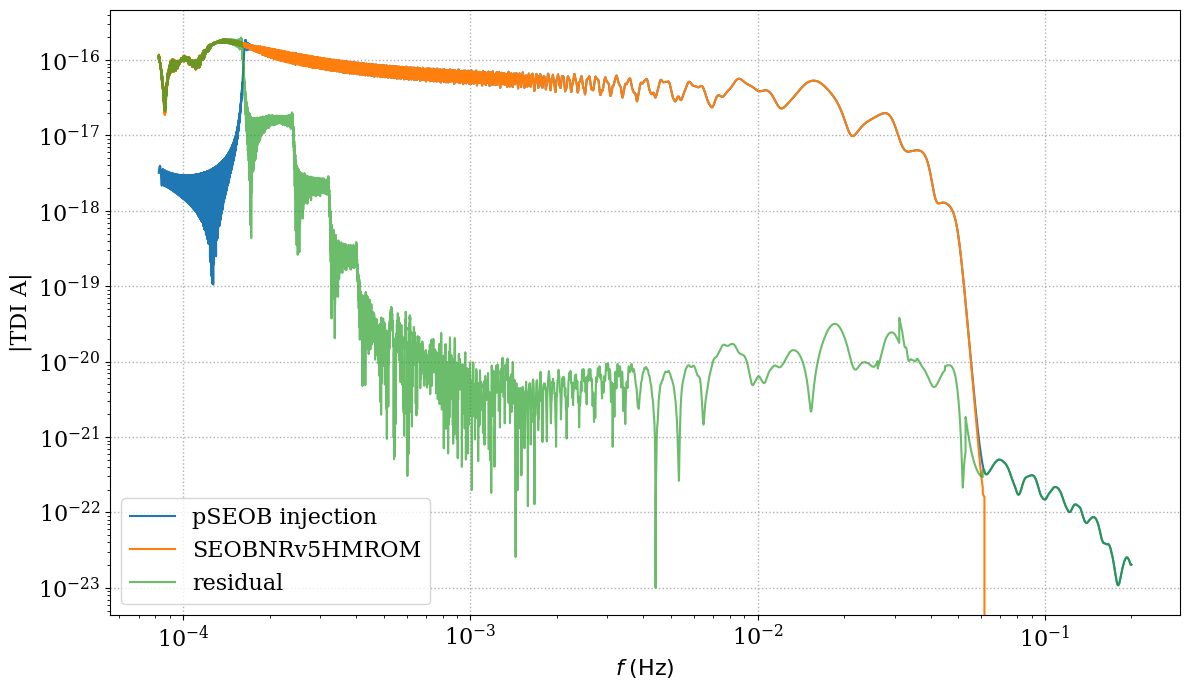

In [31]:
plt.figure(figsize=(12, 7))

plt.loglog(tdidata_nr_sur['freq'], np.abs(tdidata_nr_sur['TDIA']), label='pSEOB injection')
plt.loglog(tdi_align['freq'], np.abs(tdi_align['TDIA']), label = f'{wf_name}')
plt.loglog(residual_align['freq'], np.abs(residual_align['TDIA']), label='residual', alpha = 0.7)
# plt.loglog(f,np.sqrt(Sn_wd*f), label = '$h_n$')

plt.xlabel(r'$f \; (\mathrm{Hz})$')
plt.ylabel(r'|TDI A|')
# plt.xlim(1e-5, 0.5)
# plt.xlim(tdi_SEOB_align['freq'][0], 0.5)
# plt.ylim(1e-25,5e-16)
plt.legend(loc='lower left')
plt.tight_layout()
# fig.savefig(f'/work/LISA/piarulm/FTI/PE_analysis/Systematics_work/run_data/residual_me6.pdf')


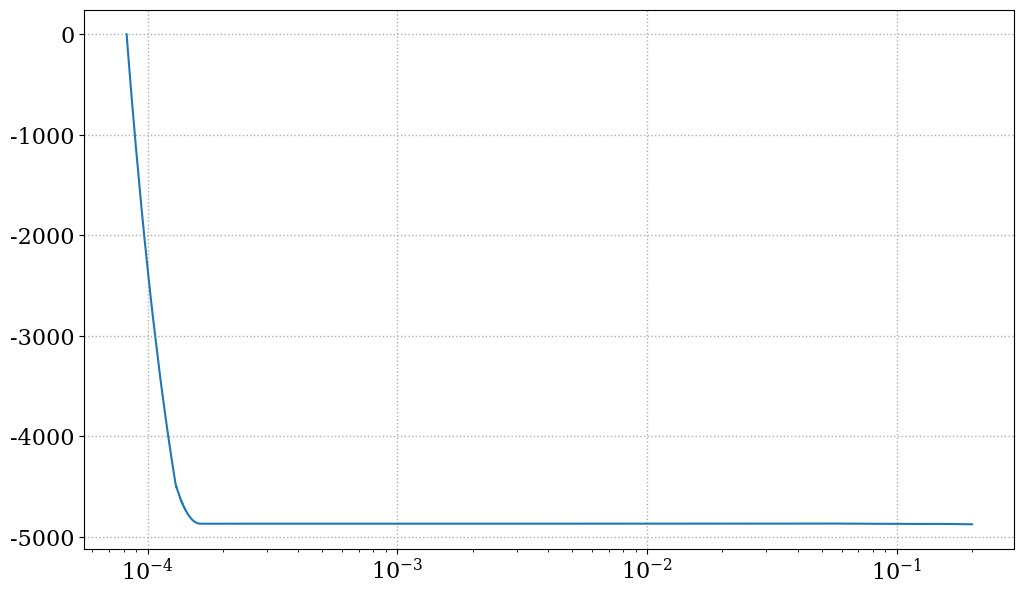

In [32]:
plt.figure(figsize=(12, 7))

plt.plot(tdidata_nr_sur['freq'], np.unwrap(np.angle(tdi_align['TDIA'])) - np.unwrap(np.angle(tdidata_nr_sur['TDIA'])))
plt.xscale('log')

### Mismatch

In [33]:
overlap_12 = overlap_AET_data(tdidata_nr_sur, tdi_align, lisa_psd)
overlap_11 = overlap_AET_data(tdidata_nr_sur, tdidata_nr_sur, lisa_psd)
overlap_22 = overlap_AET_data(tdi_align, tdi_align, lisa_psd)

norm_factor = np.sqrt(overlap_11) * np.sqrt(overlap_22)
match = np.abs(overlap_12) / norm_factor
mismatch = 1 - match

# Indistinguishability criterion
D = 11

print(f"Match (max over time, phase, pol): {match:.6f}")
print(f"Mismatch: {mismatch:.6e}")

Match (max over time, phase, pol): 0.999976
Mismatch: 2.391152e-05


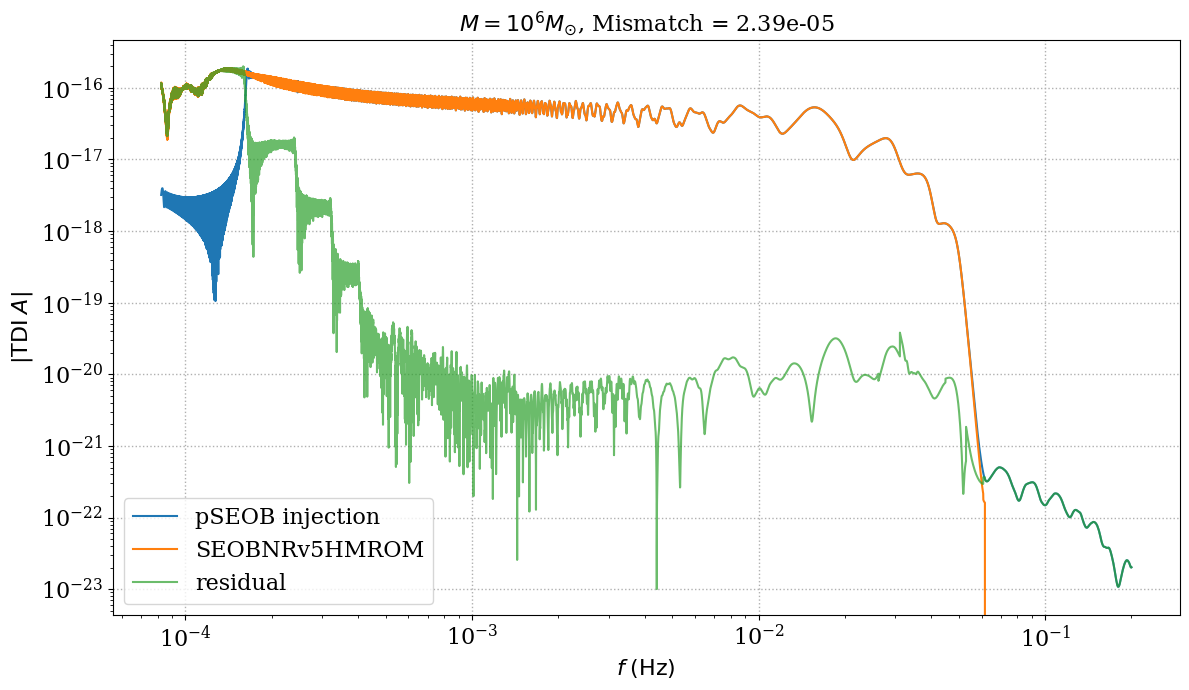

Saved figure to: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e6/$M = 10^{6} M_{\odot}$_SEOBNRv5HMROM_TDIA_residual_mismatch_2.39e-05.png


In [34]:
import os
import matplotlib.pyplot as plt

out_dir = os.path.join(datadir, m_str)
os.makedirs(out_dir, exist_ok=True)

out_file = os.path.join(
    out_dir,
    f"{mass_name}_{wf_name}_TDIA_residual_mismatch_{mismatch:.2e}.png"
)

plt.figure(figsize=(12, 7))

plt.loglog(tdidata_nr_sur['freq'], np.abs(tdidata_nr_sur['TDIA']), label='pSEOB injection')
plt.loglog(tdi_align['freq'], np.abs(tdi_align['TDIA']), label=f'{wf_name}')
plt.loglog(residual_align['freq'], np.abs(residual_align['TDIA']), label='residual', alpha=0.7)

plt.xlabel(r'$f \; (\mathrm{Hz})$')
plt.ylabel(r'$|{\rm TDI}\; A|$')
plt.legend(loc='lower left')
plt.title(rf"{mass_name}, Mismatch = {mismatch:.2e}")
plt.tight_layout()

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_file}")

In [35]:
# For the optional smooth-plot diagnostic, use the aligned template parameters.
template_params = injection_align.copy()
waveform_params_plot = waveform_params.copy()


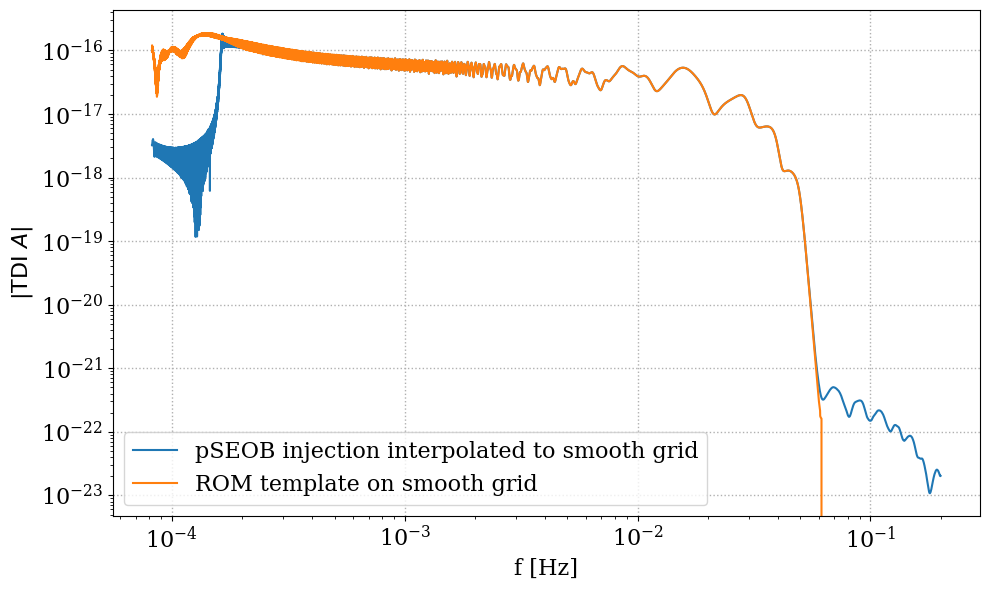

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Smooth frequency grid
freq_grid_smooth = np.geomspace(
    tdidata_nr_sur["freq"][0],
    tdidata_nr_sur["freq"][-1],
    50000
)

# Generate template on smooth grid
tdifreqseries_smooth = lisa.GenerateLISATDIFreqseries_SMBH(
    template_params,
    freq_grid_smooth,
    **waveform_params_plot
)

tdi_smooth = {
    "freq": freq_grid_smooth,
    "TDIA": np.zeros(len(freq_grid_smooth), dtype=complex),
    "TDIE": np.zeros(len(freq_grid_smooth), dtype=complex),
    "TDIT": np.zeros(len(freq_grid_smooth), dtype=complex),
}

for lm in tdifreqseries_smooth["modes"]:
    tdi_smooth["TDIA"] += tdifreqseries_smooth[lm]["chan1"]
    tdi_smooth["TDIE"] += tdifreqseries_smooth[lm]["chan2"]
    tdi_smooth["TDIT"] += tdifreqseries_smooth[lm]["chan3"]


# Interpolate injection onto the same smooth grid
tdi_inj_smooth = {
    "freq": freq_grid_smooth,
}

for chan in TDI_CHANNELS:
    inj_real = np.interp(
        freq_grid_smooth,
        tdidata_nr_sur["freq"],
        np.real(tdidata_nr_sur[chan])
    )

    inj_imag = np.interp(
        freq_grid_smooth,
        tdidata_nr_sur["freq"],
        np.imag(tdidata_nr_sur[chan])
    )

    tdi_inj_smooth[chan] = inj_real + 1j * inj_imag


# Define residual on the smooth grid
residual_smooth = {
    "freq": freq_grid_smooth,
}

for chan in TDI_CHANNELS:
    residual_smooth[chan] = tdi_smooth[chan] - tdi_inj_smooth[chan]


# Plot TDI A and residual
plt.figure(figsize=(10, 6))

plt.loglog(
    tdi_inj_smooth["freq"],
    np.abs(tdi_inj_smooth["TDIA"]),
    label="pSEOB injection interpolated to smooth grid"
)

plt.loglog(
    tdi_smooth["freq"],
    np.abs(tdi_smooth["TDIA"]),
    label="ROM template on smooth grid"
)

'''plt.loglog(
    residual_smooth["freq"],
    np.abs(residual_smooth["TDIA"]),
    label="residual on smooth grid",
    alpha=0.7
)'''

plt.xlabel("f [Hz]")
plt.ylabel(r"$|\mathrm{TDI}\ A|$")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
injection_align = pytools.complete_mass_params(injection_align)

# Sanity: beta, Fisher, covariance, and CV normalization must use the same grid/channels.
print("CV grid:", residual_align["freq"][0], residual_align["freq"][-1], len(residual_align["freq"]))
print("CV channels:", [k for k in residual_align.keys() if k != "freq"])
print("waveform_params min/max:", waveform_params["minf"], waveform_params["maxf"])

beta = dh_deltah_data_smbh(
    injection_align,
    residual_align,
    list_params=GR_param,
    Lframe=True,
    **waveform_params
)


CV grid: 8.229645274606691e-05 0.2 32723
CV channels: ['TDIA', 'TDIE', 'TDIT']
waveform_params min/max: 8.229645274606691e-05 0.2


In [38]:
fishercov = fisher_covariance_data_grid_smbh(
    injection_align,
    residual_align,
    list_params=GR_param,
    Lframe=True,
    **waveform_params
)

print("Fisher channels:", fishercov["channels"])
print("Fisher grid:", fishercov["freq"][0], fishercov["freq"][-1], len(fishercov["freq"]))
print("Fisher condition number:", fishercov["condition_number"])
print("Fisher inversion:", fishercov["inversion"])
print("Sigmas:", {p: np.sqrt(fishercov["cov"][i, i]) for i, p in enumerate(GR_param)})


Fisher channels: ['TDIA', 'TDIE', 'TDIT']
Fisher grid: 8.229645274606691e-05 0.2 32723
Fisher condition number: 2982437165499.0815
Fisher inversion: inv
Sigmas: {'Mchirp': np.float64(3.9563617572024947), 'q': np.float64(0.005349279254679418), 'chiPN': np.float64(0.000302520323312537), 'chim': np.float64(0.002384081327822076), 'Deltat': np.float64(0.08750986537340666), 'dist': np.float64(29.185313375207382), 'inc': np.float64(0.002987606073458939), 'phi': np.float64(0.016788306680726835), 'lambda': np.float64(0.0035391955215172037), 'beta': np.float64(0.0016587391752581114), 'psi': np.float64(0.004075074529374469)}


In [39]:
deltatheta = np.dot(fishercov['cov'], -beta)

cv_table = pd.DataFrame({
    "param": GR_param,
    "beta": beta,
    "delta_theta": deltatheta,
    "sigma": [np.sqrt(fishercov["cov"][i, i]) for i in range(len(GR_param))],
    "delta_theta_over_sigma": [
        deltatheta[i] / np.sqrt(fishercov["cov"][i, i])
        for i in range(len(GR_param))
    ],
})
cv_table


,param,beta,delta_theta,sigma,delta_theta_over_sigma
0,Mchirp,0.012267,0.441962,3.956362,0.111709
1,q,109.150897,0.001476,0.005349,0.275934
2,chiPN,-2772.555289,0.000072,0.000303,0.238562
3,chim,-211.398332,0.000242,0.002384,0.101663
4,Deltat,-0.376600,-0.016110,0.087510,-0.184091
5,dist,-0.036064,10.486878,29.185313,0.359320
6,inc,-324.481876,-0.000467,0.002988,-0.156375
7,phi,-0.774026,0.005210,0.016788,0.310321
8,lambda,-27.097404,0.000564,0.003539,0.159335
9,beta,-12.959943,0.000782,0.001659,0.471522


NameError: name 'base_name' is not defined

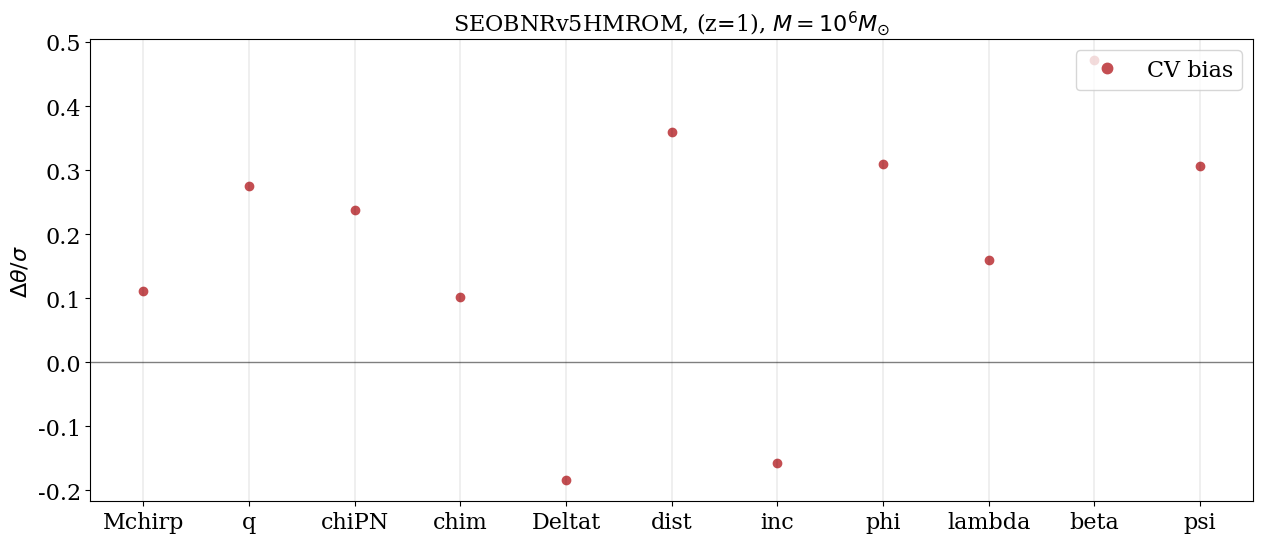

In [41]:
scales = dict([(p,np.sqrt(fishercov['cov'][i,i])) for i,p in enumerate(GR_param)])
# Set up the figure with a single subplot
fig, ax1 = plt.subplots(1, 1, figsize=[15, 6])

# --- Plot: Main Parameters ---
pos1 = np.arange(1, len(GR_param) + 1)
scat1 = [deltatheta[i] / scales[p] for i, p in enumerate(GR_param)]

# Create violin plots and scatter the CV bias points
ax1.scatter(pos1, scat1, color=plotutils.plotpalette[1])

# Formatting
ax1.set_xticks(pos1, labels=GR_param)
ax1.set_ylabel(r'$\Delta \theta / \sigma $')
ax1.set_title(f'{wf_name}, (z=1), {mass_name}')
ax1.axhline(0., c='k', lw=1., alpha=0.5)
ax1.grid(False)

# Add light vertical separators for readability
for x in pos1:
    ax1.axvline(x, c='k', lw=0.3, alpha=0.3)

# Shared Legend
handles = [
    mpl.lines.Line2D([], [], marker='.', markersize=15, color=plotutils.plotpalette[1], linestyle='None')
]
ax1.legend(handles, [r'CV bias'], loc='upper right')

# Save logic
cv_bias_repo = f"{subsdir}/run_data/cv_bias_plots/GR/{base_name}"
cv_bias_repo = f"{subsdir}/run_data"
os.makedirs(cv_bias_repo, exist_ok=True)
plt.savefig(f'{cv_bias_repo}/{run_name}_cv_bias_GR.pdf')
plt.savefig(f'{cv_bias_repo}/cv_bias_GR_{mass}_{wf_rec}.pdf')